# Figure 2: biological neural systems

Every dataset is read explicitly in its own section. Mouse, marmoset, and human
IS use Pearson correlation. C. elegans follows the original analysis: the active
NeuronOrder subset and cosine similarity of binary incoming-connectivity profiles.
Each system retains its own boxplot and FC-module clustering parameters.


In [1]:
from pathlib import Path
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    # 'font.size': 8,
    # 'axes.spines.top': False,
    # 'axes.spines.right': False,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

from figure2lib import (
    calculate_pearson_similarity_matrix,
    get_matlab_string,
    run_figure2_system,
)

FIGURE_DIR = Path("./fig/Figure2")
bio_results = {}


## C. elegans


C. elegans active matrices: (65, 65) | finite FC pairs: 4155
Modules: 5 | sizes: [13, 6, 5, 15, 26]
Minimum allowed module size: 4
Modularity Q before merging: 0.5103
Modularity Q after merging: 0.5073
Robust color limits (2-98 percentiles):
  FC: (-0.6945940915386889, 0.6945940915386889)
  IS: (-0.3868666666917626, 0.3868666666917626)
  SC: (0.0, 5.0)


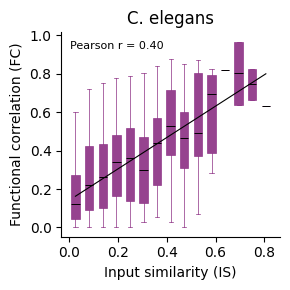

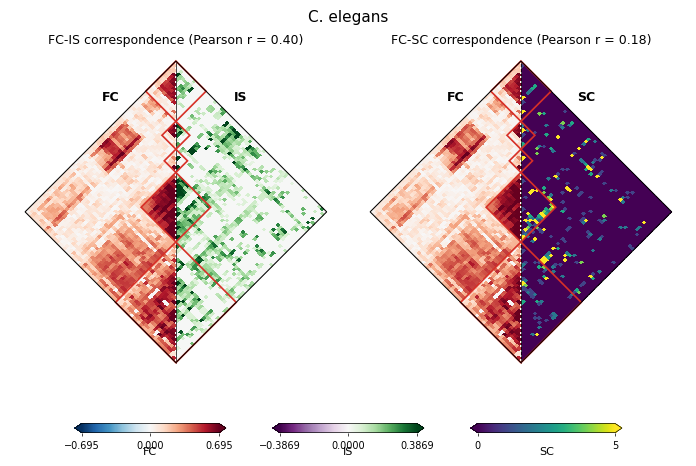

In [2]:
# Each source file is listed explicitly for easy replacement.
with h5py.File(
    "/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/"
    "C. elegans/data_uzel2022/Neuro279_EJ.mat",
    "r",
) as handle:
    celegans_electrical = np.asarray(handle["Neuro279_EJ"], dtype=float).T

with h5py.File(
    "/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/"
    "C. elegans/data_uzel2022/Neuro279_Syn.mat",
    "r",
) as handle:
    celegans_chemical = np.asarray(handle["Neuro279_Syn"], dtype=float).T

# The original analysis uses NeuronOrder (the recorded/active subset),
# rather than padding FC to all 279 connectome neurons.
with h5py.File(
    "/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/"
    "C. elegans/data_uzel2022/NeuronOrder.mat",
    "r",
) as handle:
    active_references = np.asarray(handle["NeuronOrder"]).ravel()
    active_names = [get_matlab_string(handle, ref).strip() for ref in active_references]

with h5py.File(
    "/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/"
    "C. elegans/data_uzel2022/Order279.mat",
    "r",
) as handle:
    order_references = np.asarray(handle["Order279"]).ravel()
    order279_names = [get_matlab_string(handle, ref).strip() for ref in order_references]

order279_lookup = {name: index for index, name in enumerate(order279_names)}
missing_active_names = [name for name in active_names if name not in order279_lookup]
if missing_active_names:
    raise ValueError(f"Active C. elegans neurons missing from Order279: {missing_active_names}")
active_indices_279 = np.asarray([order279_lookup[name] for name in active_names], dtype=int)

celegans_recordings = []
with h5py.File(
    "/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/"
    "C. elegans/data_uzel2022/Uzel_WT.mat",
    "r",
) as handle:
    derivative_refs = np.asarray(handle["Uzel_WT"]["derivatives"]).ravel()
    identifier_refs = np.asarray(handle["Uzel_WT"]["IDs"]).ravel()
    for derivative_ref, identifier_ref in zip(derivative_refs, identifier_refs):
        activity = np.asarray(handle[derivative_ref], dtype=float).T
        name_refs = np.asarray(handle[identifier_ref]).ravel()
        recording_names = [get_matlab_string(handle, ref).strip() for ref in name_refs]
        local_index = {name: index for index, name in enumerate(recording_names)}
        matched = [
            (global_index, local_index[name])
            for global_index, name in enumerate(active_names)
            if name in local_index
        ]
        if len(matched) < 2:
            continue
        global_indices, local_indices = map(np.asarray, zip(*matched))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            local_fc = np.corrcoef(activity[:, local_indices], rowvar=False)
        aligned_fc = np.full((len(active_names), len(active_names)), np.nan)
        aligned_fc[np.ix_(global_indices, global_indices)] = local_fc
        celegans_recordings.append(aligned_fc)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    fc_Celegans = np.abs(np.nanmean(celegans_recordings, axis=0))

# Preserve the original C. elegans definitions. SC is the weighted,
# symmetrized direct-connectivity matrix for active neurons. IS is the
# cosine similarity of binary incoming-connectivity profiles in the full
# 279-neuron connectome, then restricted to the same active neurons.
sc_279_weighted = celegans_chemical + celegans_chemical.T + celegans_electrical
sc_Celegans = sc_279_weighted[np.ix_(active_indices_279, active_indices_279)]
binary_inputs_279 = ((celegans_chemical + celegans_electrical) > 0).astype(float)
input_norms = np.linalg.norm(binary_inputs_279, axis=0)
input_denominator = np.outer(input_norms, input_norms)
is_279 = np.divide(
    binary_inputs_279.T @ binary_inputs_279,
    input_denominator,
    out=np.zeros_like(input_denominator, dtype=float),
    where=input_denominator > 0,
)
is_Celegans = np.clip(
    is_279[np.ix_(active_indices_279, active_indices_279)],
    0.0,
    1.0,
)
print(
    "C. elegans active matrices:", fc_Celegans.shape,
    "| finite FC pairs:", np.isfinite(fc_Celegans).sum(),
)

bio_results["C. elegans"] = run_figure2_system(
    "C. elegans",
    fc_Celegans,
    sc_Celegans,
    is_matrix=is_Celegans,
    group="Brain",
    output_dir=FIGURE_DIR,
    color="#8b2e83",
    num_bins=15,
    edge_density=0.10,
    resolution=1.0,
    louvain_repeats=50,
    min_module_size=0.05,
    diamond_sc_range=None,
    random_state=42,
)


## Mouse (right hemisphere)


SC-to-IS transform: log1p | nonnegative=True | n_positive=12255364 | skew=3.37 | p95/median=11.84 | scale=0.0001046
Modules: 6 | sizes: [654, 471, 709, 642, 566, 460]
Minimum allowed module size: 176
Modularity Q before merging: 0.6136
Modularity Q after merging: 0.6136
Robust color limits (2-98 percentiles):
  FC: (-0.6807, 0.6807)
  IS: (-0.9748992584844687, 0.9748992584844687)
  SC: (0.0, 0.00170515)


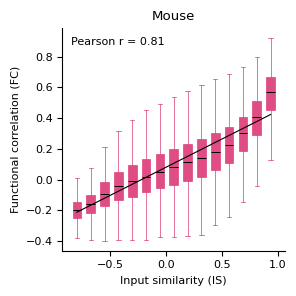

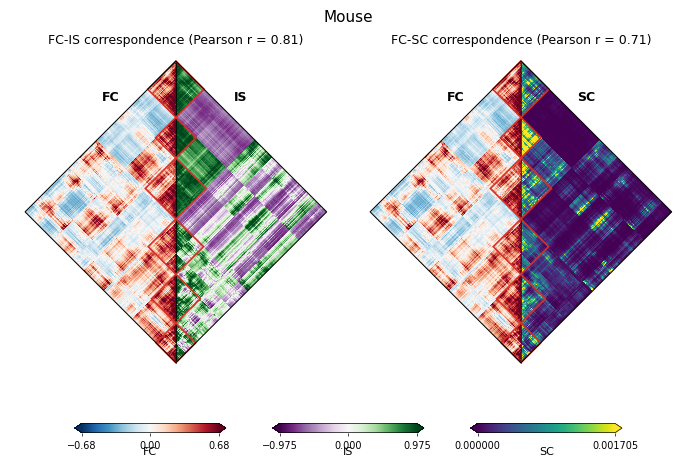

In [3]:
# Mouse matrices are read directly; change either path here.
fc_mouse_all = pd.read_csv(
    "/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/"
    "mouse_pairwisecorrelation.csv",
    index_col=0,
)
sc_mouse_all = pd.read_csv(
    "/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/"
    "mouse_couplingmatrix.csv",
    index_col=0,
)
right_labels = [
    label
    for label in fc_mouse_all.index
    if str(label).lower().startswith("right_")
]
fc_Mouse = fc_mouse_all.loc[right_labels, right_labels].to_numpy(dtype=float)
sc_Mouse = sc_mouse_all.loc[right_labels, right_labels].to_numpy(dtype=float)
is_Mouse = calculate_pearson_similarity_matrix(sc_Mouse)

# Parameters retain the previous mouse diamond range and mouse-specific layout.
bio_results["Mouse"] = run_figure2_system(
    "Mouse",
    fc_Mouse,
    sc_Mouse,
    is_matrix=is_Mouse,
    group="Brain",
    output_dir=FIGURE_DIR,
    color="#dc3977",
    num_bins=15,
    edge_density=0.10,
    resolution=1.0,
    louvain_repeats=50,
    min_module_size=0.05,
    # diamond_sc_range=(0.0, 0.17),
    random_state=42,
)


## Marmoset


SC-to-IS transform: log1p | nonnegative=True | n_positive=25154 | skew=5.69 | p95/median=64.79 | scale=0.000328641
Modules: 4 | sizes: [12, 65, 70, 45]
Minimum allowed module size: 10
Modularity Q before merging: 0.2761
Modularity Q after merging: 0.2756
Robust color limits (2-98 percentiles):
  FC: (-0.5647566915887853, 0.5647566915887853)
  IS: (-0.7917676012713117, 0.7917676012713117)
  SC: (0.0, 0.03529299411941498)


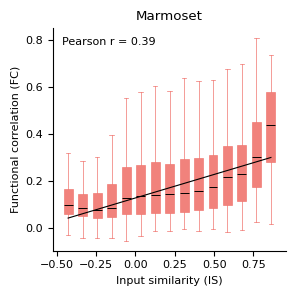

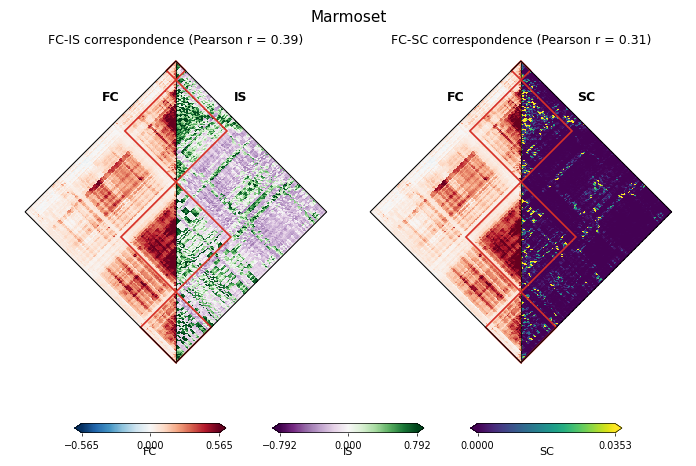

In [28]:
# Marmoset FC and SC are read explicitly from the MAT file.
marmoset_data = scipy.io.loadmat(
    "/nfs/nfs146/Data18Td/Data/haichao/connectome_data/connectome_data.mat"
)
fc_Marmoset = np.asarray(marmoset_data["MBMv4_FC"], dtype=float)
sc_Marmoset = np.asarray(marmoset_data["MBMv4_SC"], dtype=float)
is_Marmoset = calculate_pearson_similarity_matrix(sc_Marmoset)

# sc_Marmoset = np.asarray(sc_Marmoset, dtype=float)

# positive_weights = sc_Marmoset[
#     np.isfinite(sc_Marmoset) & (sc_Marmoset > 0)
# ]
# positive_scale = np.median(positive_weights)


# is_Marmoset = calculate_pearson_similarity_matrix(np.log1p(sc_Marmoset / positive_scale))

bio_results["Marmoset"] = run_figure2_system(
    "Marmoset",
    fc_Marmoset,
    sc_Marmoset,
    is_matrix=is_Marmoset,
    group="Brain",
    output_dir=FIGURE_DIR,
    color="#f0746e",
    num_bins=15,
    edge_density=0.15,
    resolution=1.0,
    louvain_repeats=50,
    min_module_size=0.05,
    # diamond_sc_range=(0.0, 0.05),
    random_state=42,
)


## Human


Human matrices: (1097, 1097)
SC-to-IS transform: log1p | nonnegative=True | n_positive=681668 | skew=16.29 | p95/median=88.71 | scale=0.01364
Modules: 4 | sizes: [248, 250, 333, 266]
Minimum allowed module size: 55
Modularity Q before merging: 0.5518
Modularity Q after merging: 0.5515
Robust color limits (2-98 percentiles):
  FC: (-0.502, 0.502)
  IS: (-0.8145289166330718, 0.8145289166330718)
  SC: (0.0, 2.121)


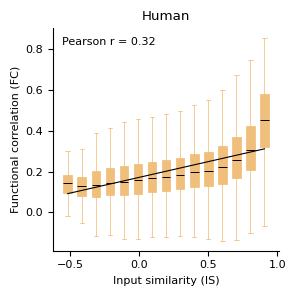

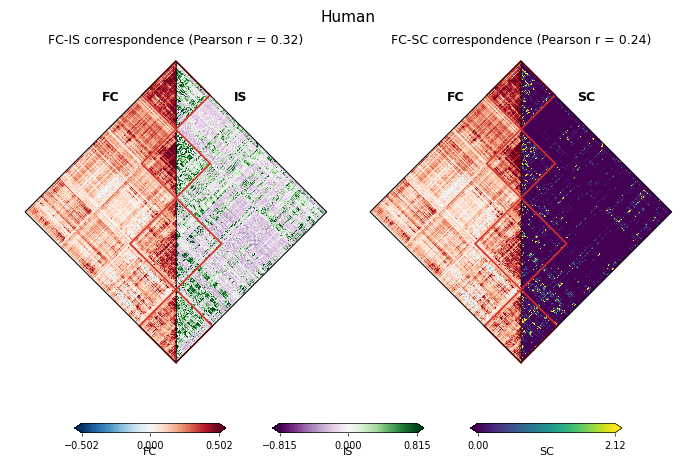

In [16]:
# Human matrices are read directly; the N1097 files match the prior main notebook.
fc_Human_frame = pd.read_csv(
    "/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/"
    "human_N1097_pairwisecorrelation.csv",
    index_col=0,
)
sc_Human_frame = pd.read_csv(
    "/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/"
    "human_N1097_couplingmatrix.csv",
    index_col=0,
)
# These two N1097 files are already stored in the same parcel order. Their
# row labels and column labels have different inferred pandas dtypes, so an
# index/column intersection incorrectly produced an empty (0, 0) matrix.
fc_Human = fc_Human_frame.to_numpy(dtype=float)
sc_Human = sc_Human_frame.to_numpy(dtype=float)
if fc_Human.shape != sc_Human.shape or fc_Human.shape[0] != fc_Human.shape[1]:
    raise ValueError(
        f"Human FC and SC must be matching square matrices; got "
        f"FC={fc_Human.shape}, SC={sc_Human.shape}."
    )
print("Human matrices:", fc_Human.shape)
is_Human = calculate_pearson_similarity_matrix(sc_Human)

# Human previously used resolution=1.5 and an SC display range of 0-0.05.
bio_results["Human"] = run_figure2_system(
    "Human",
    fc_Human,
    sc_Human,
    is_matrix=is_Human,
    group="Brain",
    output_dir=FIGURE_DIR,
    color="#f0b86e",
    num_bins=15,
    edge_density=0.10,
    resolution=1,
    louvain_repeats=50,
    min_module_size=0.05,
    # diamond_sc_range=(0.0, 0.05),
    random_state=42,
)


     Module   n_pairs     FC-IS     FC-SC
0  Module 1  205761.0  0.736719  0.675144
1  Module 2  110685.0  0.770473  0.589886
2  Module 3  213531.0  0.837575  0.704771
3  Module 4  159895.0  0.889453  0.794445
4  Module 5  250986.0  0.527007  0.394126
5  Module 6  105570.0  0.864045  0.583969
6      Mean       NaN  0.793948  0.639391


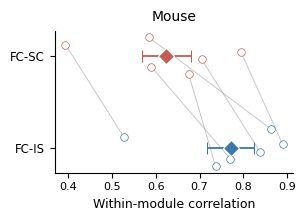

In [30]:
import numpy as np
import pandas as pd
result_dict = bio_results
system_name = 'Mouse'   # C. elegans, Mouse, Marmoset, Human
result = result_dict[system_name]
FC = np.asarray(result["matrices"]["FC"], dtype=float)
IS = np.asarray(result["matrices"]["IS"], dtype=float)
SC = np.asarray(result["matrices"]["SC"], dtype=float)
labels = np.asarray(result["diamond"]["module_labels"]).ravel()

def paired_correlation(first, second):
    valid = np.isfinite(first) & np.isfinite(second)
    first, second = first[valid], second[valid]
    if len(first) < 3 or np.ptp(first) == 0 or np.ptp(second) == 0:
        return np.nan
    return np.corrcoef(first, second)[0, 1]

rows = []
for module_number, module in enumerate(np.unique(labels), start=1):
    nodes = np.flatnonzero(labels == module)
    if len(nodes) < 3:
        r_fc_is = r_fc_sc = np.nan
        n_pairs = len(nodes) * (len(nodes) - 1) // 2
    else:
        indices = np.triu_indices(len(nodes), k=1)
        fc_values = FC[np.ix_(nodes, nodes)][indices]
        is_values = IS[np.ix_(nodes, nodes)][indices]
        sc_values = SC[np.ix_(nodes, nodes)][indices]
        r_fc_is = paired_correlation(fc_values, is_values)
        r_fc_sc = paired_correlation(fc_values, sc_values)
        n_pairs = len(fc_values)
    rows.append({
        "Module": f"Module {module_number}",
        "n_pairs": n_pairs,
        "FC-IS": r_fc_is,
        "FC-SC": r_fc_sc
    })

module_correlations = pd.DataFrame(rows)

# 仅使用 FC–IS 和 FC–SC 都有效的模块，保证两种相关性的平均基于相同模块
valid_modules = module_correlations[["FC-IS", "FC-SC"]].notna().all(axis=1)

def fisher_mean(values):
    values = np.asarray(values, dtype=float)
    values = np.clip(values, -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(values))) if len(values) else np.nan

average_row = pd.DataFrame([{
    "Module": "Mean",
    "n_pairs": np.nan,
    "FC-IS": fisher_mean(module_correlations.loc[valid_modules, "FC-IS"]),
    "FC-SC": fisher_mean(module_correlations.loc[valid_modules, "FC-SC"])
}])

module_correlations = pd.concat([module_correlations, average_row], ignore_index=True)
print(module_correlations)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = module_correlations.loc[
    (module_correlations["Module"] != "Mean") &
    module_correlations["FC-IS"].notna() &
    module_correlations["FC-SC"].notna()
].reset_index(drop=True)

values = [plot_data["FC-IS"].to_numpy(), plot_data["FC-SC"].to_numpy()]
labels = ["FC-IS", "FC-SC"]
colors = ["#3C78A8", "#C75B52"]
ypos = [1, 2]

means = [v.mean() for v in values]
sems = [v.std(ddof=1) / np.sqrt(len(v)) for v in values]
offsets = np.linspace(-0.2, 0.2, len(plot_data))

fig, ax = plt.subplots(figsize=(3.1, 2.25))

# 配对连线
for off, fc_is, fc_sc in zip(offsets, values[0], values[1]):
    ax.plot([fc_is, fc_sc], [ypos[0] + off, ypos[1] + off],
            color="#9A9A9A", linewidth=0.7, alpha=0.55,
            solid_capstyle="round", zorder=1)

# Seaborn 绘制散点
sns.scatterplot(x=values[0], y=ypos[0] + offsets, s=30,
                facecolor="white", edgecolor=colors[0],
                linewidth=0.5, ax=ax, zorder=3)

sns.scatterplot(x=values[1], y=ypos[1] + offsets, s=30,
                facecolor="white", edgecolor=colors[1],
                linewidth=0.5, ax=ax, zorder=3)

# 均值和 SEM：大菱形
for y, mean, sem, color in zip(ypos, means, sems, colors):
    ax.errorbar(mean, y, xerr=sem, fmt="D", ms=8,
                mfc=color, mec="white", mew=0.75,
                ecolor=color, elinewidth=1.3,
                capsize=4, capthick=1.2, zorder=4)

ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Within-module correlation", fontsize=9)
ax.set_ylabel("")
ax.set_title(system_name, fontsize=10, pad=7)
# ax.tick_params(axis="x", labelsize=8)
# ax.tick_params(axis="y", length=0)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig(FIGURE_DIR / f"Figure2_{system_name}_FC_IS_SC.pdf",
            format="pdf", bbox_inches="tight")
plt.show()